# Model performance report (validation)

Read-only notebook over saved tournament artifacts. **No training. Test and score stay sealed.**

It graphs the essential results, explains what each metric means in this project, and writes down what the comparison actually says.

| | Path |
|---|---|
| This notebook | `data/quality_reports/model_performance_report.ipynb` |
| Figures | `data/quality_reports/modeling/figures/` |
| Leaderboard | `data/gold/modeling/artifacts/metrics/validation_leaderboard.csv` |
| Freeze note | `docs/final_model_freeze.md` |
| Eval protocol | `data/quality_reports/modeling/eval_protocol.md` |

**Question:** which MISO queue projects will withdraw in the next 12 months?

**Rule:** train on 2020–2022, pick the model on 2023 val, do not peek at 2024 test.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ACCENT = "#2F6FED"
GREEN = "#1B7F4E"
AMBER = "#B45309"
RED = "#B42318"
GRAY = "#6B7280"
MUTED = "#9CA3AF"

HERE = Path.cwd().resolve()
REPO = None
for p in [HERE, *HERE.parents]:
    if (p / "Data" / "gold").is_dir() or (p / "data" / "gold").is_dir():
        REPO = p
        break
if REPO is None:
    raise FileNotFoundError("Could not find repo root (Data/gold).")

DATA = REPO / "Data" if (REPO / "Data" / "gold").is_dir() else REPO / "data"
METRICS = DATA / "gold" / "modeling" / "artifacts" / "metrics"
CALIB = DATA / "gold" / "modeling" / "artifacts" / "calibration"
GOLD = DATA / "gold"
FIG = DATA / "quality_reports" / "modeling" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
NASNET = REPO / "reports" / "models" / "nasnet" / "nasnet_validation_metrics.json"


def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def savefig(fig, name: str) -> Path:
    out = FIG / name
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    return out


def hline(ax, y, label, color=GRAY, ls="--"):
    ax.axhline(y, color=color, ls=ls, lw=1)
    ax.text(1.01, y, label, transform=ax.get_yaxis_transform(), va="center",
            color=color, fontsize=9)


def vline(ax, x, label, color=GRAY, ls="--"):
    ax.axvline(x, color=color, ls=ls, lw=1)
    ax.text(x, 1.02, label, transform=ax.get_xaxis_transform(), ha="center",
            va="bottom", color=color, fontsize=9)


champion = load_json(GOLD / "modeling" / "artifacts" / "champion.json")
goal_status = load_json(METRICS / "goal_status.json")
split_manifest = load_json(GOLD / "split_manifest.json")
prep = load_json(DATA / "quality_reports" / "modeling" / "preprocessing_summary.json")
baseline_sum = load_json(METRICS / "val_baseline_leaderboard_summary.json")
leaderboard = pd.read_csv(METRICS / "validation_leaderboard.csv")
baselines = pd.read_csv(METRICS / "val_baseline_leaderboard.csv")
seeds = pd.read_csv(METRICS / "catboost_champion_seed_stability.csv")
ftt = load_json(METRICS / "ft_transformer_vs_baselines.json")
autogluon = pd.DataFrame(load_json(METRICS / "autogluon_benchmark.json"))
ablation_raw = load_json(METRICS / "top_model_ablations.json")
calib = load_json(CALIB / "catboost_tuned" / "summary.json")
nasnet = load_json(NASNET) if NASNET.exists() else {}
surv_md = (METRICS / "survival_tournament.md").read_text(encoding="utf-8")

n_train = prep["nan_check"]["train"]["n_rows"]
n_val = prep["nan_check"]["val"]["n_rows"]
n_test = prep["nan_check"]["test"]["n_rows"]
n_score = prep["nan_check"]["score"]["n_rows"]
prev_train = baseline_sum["sanity_baselines"]["train"]["prevalence"]
prev_val = baseline_sum["sanity_baselines"]["val"]["prevalence"]

deploy = calib["methods"]["platt"]["raw_val"]
platt_cv = calib["methods"]["platt"]["cross_fitted_primary"]
iso_cv = calib["methods"]["isotonic"]["cross_fitted_primary"]

STRONG = {"pr_auc": 0.10, "pr_lift": 2.5, "roc_auc": 0.74, "log_loss": 0.195, "mw": 0.22}
STRETCH = {"pr_auc": 0.12, "pr_lift": 3.0, "roc_auc": 0.78, "log_loss": 0.185, "mw": 0.28}

print(f"REPO     {REPO}")
print(f"Figures  {FIG}")
print(f"Val n    {n_val:,}   prevalence {prev_val:.4f}   no-skill PR-AUC = {prev_val:.4f}")
print(f"Test/score sealed: {champion.get('test_sealed', True)}")


REPO     C:\Users\Magjun\Documents\Team-8-XternChallenge-
Figures  C:\Users\Magjun\Documents\Team-8-XternChallenge-\Data\quality_reports\modeling\figures
Val n    1,666   prevalence 0.0414   no-skill PR-AUC = 0.0414
Test/score sealed: True


## 1. Data splits

We do **not** shuffle rows. Time moves forward:

| Split | Years | Modeling rows | Dropout rate | Role |
|---|---|---:|---:|---|
| **Train** | 2020–2022 | 3,277 | 12.4% | Fit the model |
| **Val** | 2023 | 1,666 | 4.1% | Pick the winner |
| **Test** | 2024 | 2,204 | locked | Final check — not opened |
| **Score** | 2025–2026 | 2,676 | locked | Live queue to rank later |

Train has many more dropouts than val. A model that just “remembers 2020–22” will look worse on 2023. That is intended.

**No-skill PR-AUC on val = 0.041** (the val dropout rate). Do not compare against the train rate of 0.124.


,split,years,rows,dropout_rate,role
0,train,2020–2022,"3,277",12.4%,fit
1,val,2023,"1,666",4.1%,select
2,test,2024,"2,204",locked,sealed
3,score,2025–2026,"2,676",locked,sealed


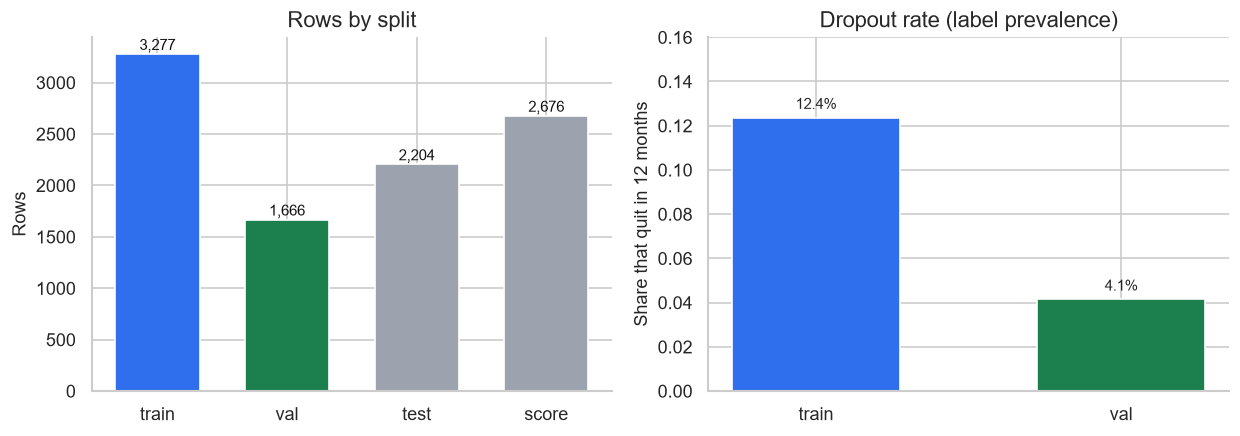

In [2]:
split_df = pd.DataFrame({
    "split": ["train", "val", "test", "score"],
    "years": ["2020–2022", "2023", "2024", "2025–2026"],
    "rows": [n_train, n_val, n_test, n_score],
    "dropout_rate": [prev_train, prev_val, np.nan, np.nan],
    "role": ["fit", "select", "sealed", "sealed"],
})
display(split_df.style.format({"rows": "{:,}", "dropout_rate": "{:.1%}"}, na_rep="locked"))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
colors = [ACCENT, GREEN, MUTED, MUTED]
axes[0].bar(split_df["split"], split_df["rows"], color=colors, width=0.65)
axes[0].set_title("Rows by split")
axes[0].set_ylabel("Rows")
for i, v in enumerate(split_df["rows"]):
    axes[0].text(i, v + 40, f"{v:,}", ha="center", fontsize=9, color="#111")

axes[1].bar(["train", "val"], [prev_train, prev_val], color=[ACCENT, GREEN], width=0.55)
axes[1].set_title("Dropout rate (label prevalence)")
axes[1].set_ylabel("Share that quit in 12 months")
axes[1].set_ylim(0, 0.16)
axes[1].text(0, prev_train + 0.004, f"{prev_train:.1%}", ha="center", fontsize=9)
axes[1].text(1, prev_val + 0.004, f"{prev_val:.1%}", ha="center", fontsize=9)
fig.tight_layout()
savefig(fig, "01_splits.png")
plt.show()

n_pos_val = int(round(n_val * prev_val))
display(HTML(
    f"<div style='display:flex;gap:12px;flex-wrap:wrap;font-family:sans-serif'>"
    f"<div style='padding:12px 16px;background:#f3f4f6;border-radius:8px'>"
    f"<div style='font-size:22px;font-weight:600'>{n_val:,}</div>"
    f"<div style='color:#6b7280;font-size:12px'>val projects</div></div>"
    f"<div style='padding:12px 16px;background:#f3f4f6;border-radius:8px'>"
    f"<div style='font-size:22px;font-weight:600'>{n_pos_val}</div>"
    f"<div style='color:#6b7280;font-size:12px'>val withdrawals (~{prev_val:.1%})</div></div>"
    f"<div style='padding:12px 16px;background:#ecfdf3;border-radius:8px'>"
    f"<div style='font-size:22px;font-weight:600;color:#1b7f4e'>{champion['pr_auc']:.3f}</div>"
    f"<div style='color:#6b7280;font-size:12px'>champion PR-AUC (peak)</div></div>"
    f"<div style='padding:12px 16px;background:#eff6ff;border-radius:8px'>"
    f"<div style='font-size:22px;font-weight:600;color:#2f6fed'>{deploy['pr_auc']:.3f}</div>"
    f"<div style='color:#6b7280;font-size:12px'>deploy CatBoost PR-AUC</div></div>"
    f"</div>"
))


## 2. What the tests mean

The model gives every project a **risk score** (close to 1 = more likely to quit). Each metric is a different question about that score.

### Ranking: “do real quitters sit near the top?”

| Metric | Question in plain words | Chance / floor on this val set | Higher or lower? |
|---|---|---|---|
| **PR-AUC** | Are we actually good at finding the *rare* quitters? | **0.041** (the dropout rate) | higher |
| **ROC-AUC** | If we pick one quitter and one stayer, how often does the quitter get the higher score? | **0.50** | higher |
| **PR-lift** | PR-AUC divided by chance. “How many times better than guessing?” | **1.0×** | higher |
| **Precision@10%** | Of the 10% we flagged as riskiest, how many really quit? | ~4% | higher |
| **Recall@10%** | Of *all* real quitters, what share did that top 10% catch? | 10% if random | higher |
| **MW@10%** | Of all *megawatts* that quit, what share did the top 10% catch? | ~10% if random | higher |

**Why PR-AUC is the main score, not ROC-AUC.** Quitters are only 4% of val. ROC can look “pretty good” (0.7+) while you still miss most quitters. PR-AUC uses the rare class as the baseline, so 0.14 vs 0.041 is the honest win.

AUC means **area under the curve** — one number that summarizes a whole tradeoff graph.

- **ROC curve:** false-alarm rate vs catch rate. Area = ROC-AUC.
- **PR curve:** precision vs recall. Area = PR-AUC.

### Honesty: “if it says 30%, is it really about 30%?”

| Metric | Question | Lower or higher? |
|---|---|---|
| **Log-loss** | How painful are confident wrong answers? | lower (strong ≤ 0.195) |
| **Brier** | Average squared error of the predicted %. Constant 4.1% guess ≈ 0.040 | lower |
| **ECE** | Bin projects by predicted %; does each bin’s real quit rate match? | lower |

We **rank** with PR-AUC / recall / MW. We **quote a probability** after Platt calibration (Brier / ECE / log-loss).

### Team bars (val)

| | PR-AUC | PR-lift | ROC-AUC | Log-loss | MW@10% |
|---|---:|---:|---:|---:|---:|
| Strong | ≥ 0.10 | ≥ 2.5 | ≥ 0.74 | ≤ 0.195 | ≥ 0.22 |
| Stretch | ≥ 0.12 | ≥ 3.0 | ≥ 0.78 | ≤ 0.185 | ≥ 0.28 |


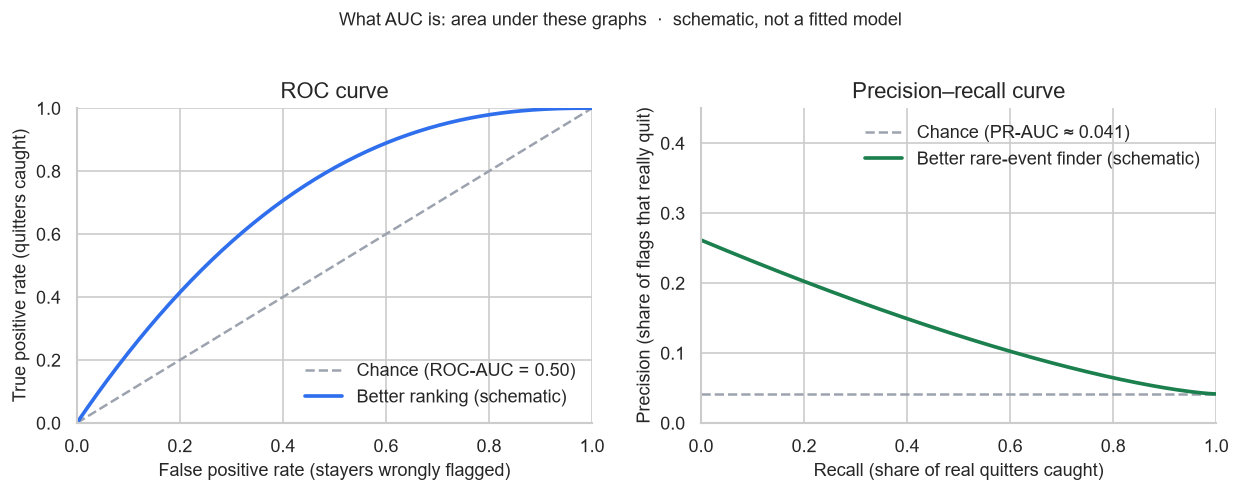

In [3]:
# Didactic ROC vs PR: chance lines on this dataset (no model predictions required).
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

fpr = np.linspace(0, 1, 200)
axes[0].plot(fpr, fpr, color=MUTED, ls="--", label="Chance (ROC-AUC = 0.50)")
# Schematic "good" ROC (not a fitted curve — illustration only)
tpr = np.clip(1 - (1 - fpr) ** 2.4, 0, 1)
axes[0].plot(fpr, tpr, color=ACCENT, lw=2.2, label="Better ranking (schematic)")
axes[0].set_xlabel("False positive rate (stayers wrongly flagged)")
axes[0].set_ylabel("True positive rate (quitters caught)")
axes[0].set_title("ROC curve")
axes[0].legend(frameon=False, loc="lower right")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

recall = np.linspace(0, 1, 200)
axes[1].axhline(prev_val, color=MUTED, ls="--", label=f"Chance (PR-AUC ≈ {prev_val:.3f})")
prec = np.clip(prev_val + 0.22 * (1 - recall) ** 1.4, prev_val, 1)
axes[1].plot(recall, prec, color=GREEN, lw=2.2, label="Better rare-event finder (schematic)")
axes[1].set_xlabel("Recall (share of real quitters caught)")
axes[1].set_ylabel("Precision (share of flags that really quit)")
axes[1].set_title("Precision–recall curve")
axes[1].legend(frameon=False, loc="upper right")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 0.45)
fig.suptitle("What AUC is: area under these graphs  ·  schematic, not a fitted model",
             fontsize=11, y=1.02)
fig.tight_layout()
savefig(fig, "02_auc_meaning.png")
plt.show()


## 3. Model comparison (val 2023)

Headline numbers from the freeze package and family-best rows. CatBoost **peak** is the lucky HPO trial (seed 42 during search). CatBoost **deploy** is the saved `catboost_tuned` model (seed 2026) used with Platt.


model,role,pr_auc,pr_lift,roc_auc,log_loss,precision_at_10pct,recall_at_10pct,mw_at_10pct,goal
CatBoost peak (trial 149),VAL champion,0.144,3.486,0.794,0.187,0.156,0.377,0.335,strong
CatBoost deploy (tuned),ship this,0.121,2.930,0.799,0.156,0.132,0.319,0.291,strong
LightGBM tuned,runner-up,0.141,3.394,0.774,0.210,0.174,0.420,0.451,below_strong
Ensemble (log-loss mix),blend,0.121,2.930,0.799,0.156,0.132,0.319,0.291,strong
XGBoost tuned,tree,0.120,2.903,0.764,0.213,0.132,0.319,0.277,below_strong
FT-Transformer,not promoted,0.087,2.098,0.641,0.768,—,—,0.184,below_strong
CatBoost default (untuned),baseline,0.081,1.945,0.698,0.206,—,—,—,baseline
AutoGluon medium,below,0.065,1.569,0.630,0.213,0.090,0.217,0.182,below_strong
TabM,below,0.056,1.343,0.615,0.195,—,—,0.114,below_strong
NASNet (closed),closed,0.056,1.346,0.508,0.566,0.024,0.058,0.068,closed


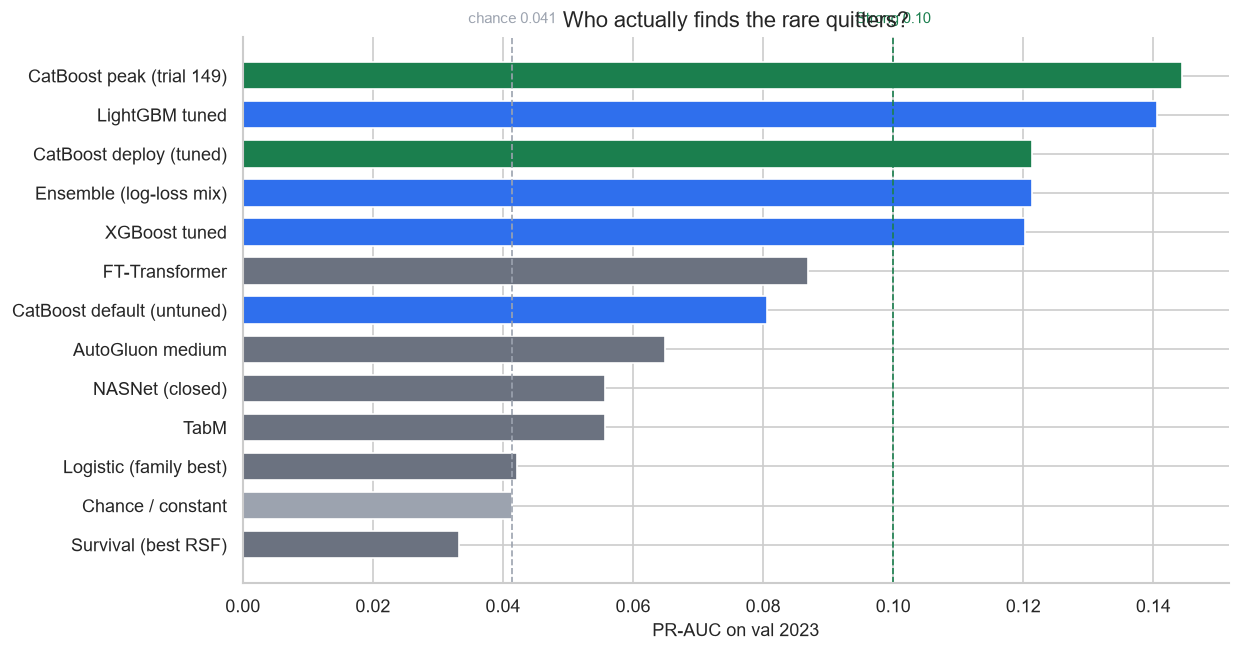

In [4]:
headline = pd.DataFrame([
    {
        "model": "CatBoost peak (trial 149)",
        "family": "catboost",
        "role": "VAL champion",
        "pr_auc": champion["pr_auc"],
        "pr_lift": champion["pr_lift"],
        "roc_auc": champion["roc_auc"],
        "log_loss": champion["log_loss"],
        "brier": champion["brier"],
        "precision_at_10pct": champion["precision_at_10pct"],
        "recall_at_10pct": champion["recall_at_10pct"],
        "mw_at_10pct": champion["withdrawn_mw_capture_at_10pct"],
        "goal": champion["goal"],
    },
    {
        "model": "CatBoost deploy (tuned)",
        "family": "catboost",
        "role": "ship this",
        "pr_auc": deploy["pr_auc"],
        "pr_lift": deploy["pr_auc"] / prev_val,
        "roc_auc": deploy["roc_auc"],
        "log_loss": deploy["log_loss"],
        "brier": deploy["brier"],
        "precision_at_10pct": calib["methods"]["platt"]["full_val_ops"]["precision_at_10pct"],
        "recall_at_10pct": calib["methods"]["platt"]["full_val_ops"]["recall_at_10pct"],
        "mw_at_10pct": calib["methods"]["platt"]["full_val_ops"]["withdrawn_mw_capture_at_10pct"],
        "goal": "strong",
    },
    {
        "model": "LightGBM tuned",
        "family": "lightgbm",
        "role": "runner-up",
        "pr_auc": goal_status["lightgbm"]["pr_auc"],
        "pr_lift": goal_status["lightgbm"]["pr_lift"],
        "roc_auc": goal_status["lightgbm"]["roc_auc"],
        "log_loss": goal_status["lightgbm"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": leaderboard.loc[leaderboard["model"] == "lightgbm_tuned", "precision_at_10pct"].iloc[0],
        "recall_at_10pct": leaderboard.loc[leaderboard["model"] == "lightgbm_tuned", "recall_at_10pct"].iloc[0],
        "mw_at_10pct": goal_status["lightgbm"]["withdrawn_mw_capture_at_10pct"],
        "goal": goal_status["lightgbm"]["goal"],
    },
    {
        "model": "Ensemble (log-loss mix)",
        "family": "ensemble",
        "role": "blend",
        "pr_auc": goal_status["ensemble"]["pr_auc"],
        "pr_lift": goal_status["ensemble"]["pr_lift"],
        "roc_auc": goal_status["ensemble"]["roc_auc"],
        "log_loss": goal_status["ensemble"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": leaderboard.loc[leaderboard["model"] == "ensemble_log_loss", "precision_at_10pct"].iloc[0],
        "recall_at_10pct": leaderboard.loc[leaderboard["model"] == "ensemble_log_loss", "recall_at_10pct"].iloc[0],
        "mw_at_10pct": goal_status["ensemble"]["withdrawn_mw_capture_at_10pct"],
        "goal": goal_status["ensemble"]["goal"],
    },
    {
        "model": "XGBoost tuned",
        "family": "xgboost",
        "role": "tree",
        "pr_auc": goal_status["xgboost"]["pr_auc"],
        "pr_lift": goal_status["xgboost"]["pr_lift"],
        "roc_auc": goal_status["xgboost"]["roc_auc"],
        "log_loss": goal_status["xgboost"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": leaderboard.loc[leaderboard["model"] == "xgboost_tuned", "precision_at_10pct"].iloc[0],
        "recall_at_10pct": leaderboard.loc[leaderboard["model"] == "xgboost_tuned", "recall_at_10pct"].iloc[0],
        "mw_at_10pct": goal_status["xgboost"]["withdrawn_mw_capture_at_10pct"],
        "goal": goal_status["xgboost"]["goal"],
    },
    {
        "model": "FT-Transformer",
        "family": "neural",
        "role": "not promoted",
        "pr_auc": ftt["ft_transformer"]["pr_auc"],
        "pr_lift": ftt["ft_transformer"]["pr_auc"] / prev_val,
        "roc_auc": ftt["ft_transformer"]["roc_auc"],
        "log_loss": ftt["ft_transformer"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": np.nan,
        "recall_at_10pct": np.nan,
        "mw_at_10pct": ftt["ft_transformer"]["withdrawn_mw_capture_at_10pct"],
        "goal": "below_strong",
    },
    {
        "model": "CatBoost default (untuned)",
        "family": "catboost",
        "role": "baseline",
        "pr_auc": baselines.loc[baselines["model"] == "catboost", "pr_auc"].iloc[0],
        "pr_lift": baselines.loc[baselines["model"] == "catboost", "pr_auc"].iloc[0] / prev_val,
        "roc_auc": baselines.loc[baselines["model"] == "catboost", "roc_auc"].iloc[0],
        "log_loss": baselines.loc[baselines["model"] == "catboost", "log_loss"].iloc[0],
        "brier": baselines.loc[baselines["model"] == "catboost", "brier"].iloc[0],
        "precision_at_10pct": np.nan,
        "recall_at_10pct": np.nan,
        "mw_at_10pct": np.nan,
        "goal": "baseline",
    },
    {
        "model": "AutoGluon medium",
        "family": "automl",
        "role": "below",
        "pr_auc": autogluon.loc[autogluon["preset"] == "medium_quality", "pr_auc"].iloc[0],
        "pr_lift": autogluon.loc[autogluon["preset"] == "medium_quality", "pr_lift"].iloc[0],
        "roc_auc": autogluon.loc[autogluon["preset"] == "medium_quality", "roc_auc"].iloc[0],
        "log_loss": autogluon.loc[autogluon["preset"] == "medium_quality", "log_loss"].iloc[0],
        "brier": autogluon.loc[autogluon["preset"] == "medium_quality", "brier"].iloc[0],
        "precision_at_10pct": autogluon.loc[autogluon["preset"] == "medium_quality", "precision_at_10pct"].iloc[0],
        "recall_at_10pct": autogluon.loc[autogluon["preset"] == "medium_quality", "recall_at_10pct"].iloc[0],
        "mw_at_10pct": autogluon.loc[autogluon["preset"] == "medium_quality", "withdrawn_mw_capture_at_10pct"].iloc[0],
        "goal": "below_strong",
    },
    {
        "model": "TabM",
        "family": "neural",
        "role": "below",
        "pr_auc": goal_status["tabm"]["pr_auc"],
        "pr_lift": goal_status["tabm"]["pr_lift"],
        "roc_auc": goal_status["tabm"]["roc_auc"],
        "log_loss": goal_status["tabm"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": np.nan,
        "recall_at_10pct": np.nan,
        "mw_at_10pct": goal_status["tabm"]["withdrawn_mw_capture_at_10pct"],
        "goal": goal_status["tabm"]["goal"],
    },
    {
        "model": "NASNet (closed)",
        "family": "neural",
        "role": "closed",
        "pr_auc": nasnet.get("pr_auc", ftt["baselines"]["nasnet"]["pr_auc"]),
        "pr_lift": nasnet.get("pr_lift", np.nan),
        "roc_auc": nasnet.get("roc_auc", ftt["baselines"]["nasnet"]["roc_auc"]),
        "log_loss": nasnet.get("log_loss", ftt["baselines"]["nasnet"]["log_loss"]),
        "brier": nasnet.get("brier", np.nan),
        "precision_at_10pct": nasnet.get("precision_at_10pct", np.nan),
        "recall_at_10pct": nasnet.get("recall_at_10pct", np.nan),
        "mw_at_10pct": nasnet.get("withdrawn_mw_capture_at_10pct", ftt["baselines"]["nasnet"]["withdrawn_mw_capture_at_10pct"]),
        "goal": "closed",
    },
    {
        "model": "Logistic (family best)",
        "family": "linear",
        "role": "below",
        "pr_auc": goal_status["logistic"]["pr_auc"],
        "pr_lift": goal_status["logistic"]["pr_lift"],
        "roc_auc": goal_status["logistic"]["roc_auc"],
        "log_loss": goal_status["logistic"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": np.nan,
        "recall_at_10pct": np.nan,
        "mw_at_10pct": goal_status["logistic"]["withdrawn_mw_capture_at_10pct"],
        "goal": goal_status["logistic"]["goal"],
    },
    {
        "model": "Survival (best RSF)",
        "family": "survival",
        "role": "below",
        "pr_auc": goal_status["survival"]["pr_auc"],
        "pr_lift": np.nan,
        "roc_auc": goal_status["survival"]["roc_auc"],
        "log_loss": goal_status["survival"]["log_loss"],
        "brier": np.nan,
        "precision_at_10pct": 0.0,
        "recall_at_10pct": 0.0,
        "mw_at_10pct": goal_status["survival"]["withdrawn_mw_capture_at_10pct"],
        "goal": goal_status["survival"]["goal"],
    },
    {
        "model": "Chance / constant",
        "family": "baseline",
        "role": "no-skill",
        "pr_auc": prev_val,
        "pr_lift": 1.0,
        "roc_auc": 0.5,
        "log_loss": baselines.loc[baselines["model"] == "constant", "log_loss"].iloc[0],
        "brier": baselines.loc[baselines["model"] == "constant", "brier"].iloc[0],
        "precision_at_10pct": prev_val,
        "recall_at_10pct": 0.10,
        "mw_at_10pct": np.nan,
        "goal": "baseline",
    },
])

show_cols = [
    "model", "role", "pr_auc", "pr_lift", "roc_auc", "log_loss",
    "precision_at_10pct", "recall_at_10pct", "mw_at_10pct", "goal",
]
fmt = {c: "{:.3f}" for c in show_cols if c not in ("model", "role", "goal")}
display(headline[show_cols].style.format(fmt, na_rep="—").hide(axis="index"))

plot_h = headline.sort_values("pr_auc", ascending=True)
colors = []
for _, r in plot_h.iterrows():
    if r["role"] in {"VAL champion", "ship this"}:
        colors.append(GREEN)
    elif r["family"] in {"catboost", "lightgbm", "xgboost", "ensemble"}:
        colors.append(ACCENT)
    elif r["role"] == "no-skill":
        colors.append(MUTED)
    else:
        colors.append(GRAY)

fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.barh(plot_h["model"], plot_h["pr_auc"], color=colors, height=0.7)
vline(ax, prev_val, "chance 0.041", MUTED)
vline(ax, STRONG["pr_auc"], "Strong 0.10", GREEN)
ax.set_xlabel("PR-AUC on val 2023")
ax.set_title("Who actually finds the rare quitters?")
fig.tight_layout()
savefig(fig, "03_pr_auc_headline.png")
plt.show()


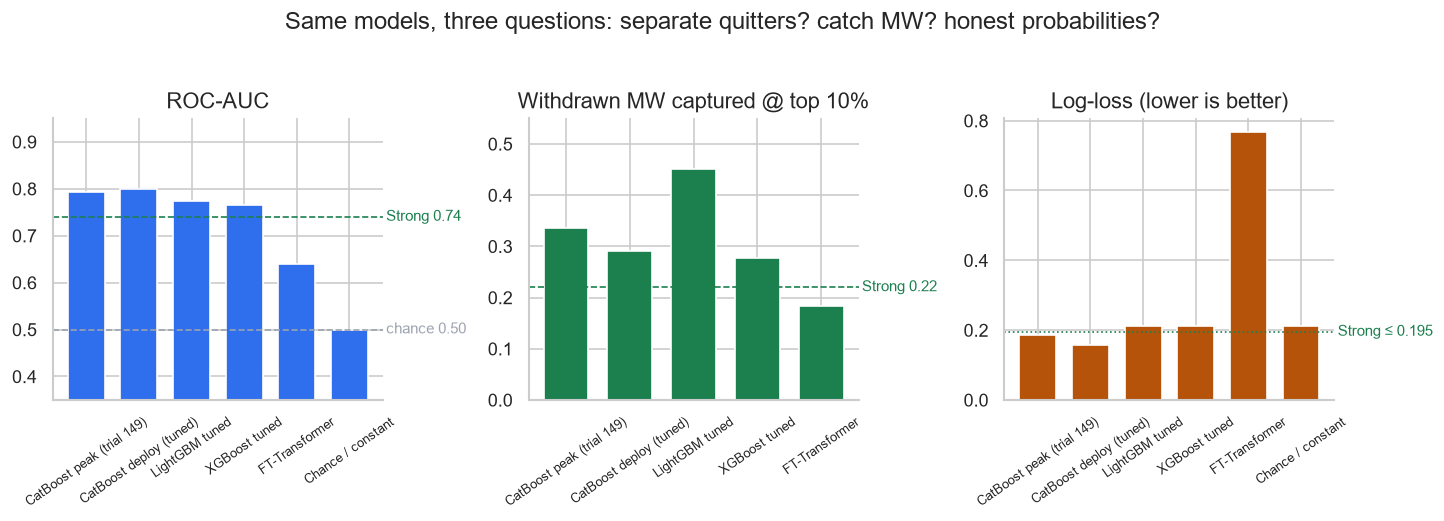

In [5]:
# Side-by-side: ranking vs ops vs honesty for the models we would actually discuss.
focus = headline[headline["model"].isin([
    "CatBoost peak (trial 149)",
    "CatBoost deploy (tuned)",
    "LightGBM tuned",
    "XGBoost tuned",
    "FT-Transformer",
    "Chance / constant",
])].copy()
order = [
    "CatBoost peak (trial 149)",
    "CatBoost deploy (tuned)",
    "LightGBM tuned",
    "XGBoost tuned",
    "FT-Transformer",
    "Chance / constant",
]
focus["model"] = pd.Categorical(focus["model"], order, ordered=True)
focus = focus.sort_values("model")

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.2))

axes[0].bar(focus["model"], focus["roc_auc"], color=ACCENT, width=0.7)
hline(axes[0], 0.5, "chance 0.50", MUTED)
hline(axes[0], STRONG["roc_auc"], "Strong 0.74", GREEN)
axes[0].set_title("ROC-AUC")
axes[0].set_ylim(0.35, 0.95)
axes[0].tick_params(axis="x", rotation=35, labelsize=8)

axes[1].bar(focus["model"], focus["mw_at_10pct"], color=GREEN, width=0.7)
hline(axes[1], STRONG["mw"], "Strong 0.22", GREEN)
axes[1].set_title("Withdrawn MW captured @ top 10%")
axes[1].set_ylim(0, 0.55)
axes[1].tick_params(axis="x", rotation=35, labelsize=8)

axes[2].bar(focus["model"], focus["log_loss"], color=AMBER, width=0.7)
hline(axes[2], STRONG["log_loss"], "Strong ≤ 0.195", GREEN, ls=":")
axes[2].set_title("Log-loss (lower is better)")
axes[2].tick_params(axis="x", rotation=35, labelsize=8)

for ax in axes:
    ax.set_xlabel("")
fig.suptitle("Same models, three questions: separate quitters? catch MW? honest probabilities?", y=1.03)
fig.tight_layout()
savefig(fig, "04_roc_mw_logloss.png")
plt.show()


## 4. If we only watch the riskiest 10%

Val has **1,666** projects and about **69** withdrawals. Top 10% is about **167** projects.

Precision 16% still means **most flagged projects stay**. The model is a triage list, not a verdict.


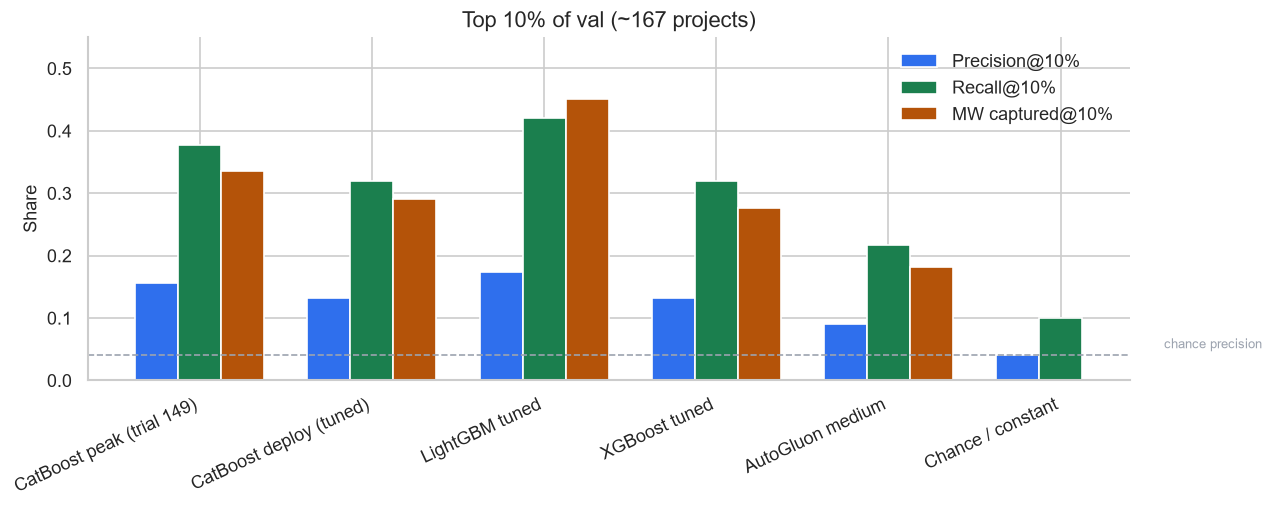

model,precision_at_10pct,recall_at_10pct,mw_at_10pct
CatBoost peak (trial 149),15.6%,37.7%,33.5%
CatBoost deploy (tuned),13.2%,31.9%,29.1%
LightGBM tuned,17.4%,42.0%,45.1%
XGBoost tuned,13.2%,31.9%,27.7%
AutoGluon medium,9.0%,21.7%,18.2%
Chance / constant,4.1%,10.0%,nan%


In [6]:
ops = headline[headline["model"].isin([
    "CatBoost peak (trial 149)",
    "CatBoost deploy (tuned)",
    "LightGBM tuned",
    "XGBoost tuned",
    "AutoGluon medium",
    "Chance / constant",
])].copy()
ops["model"] = pd.Categorical(ops["model"], [
    "CatBoost peak (trial 149)",
    "CatBoost deploy (tuned)",
    "LightGBM tuned",
    "XGBoost tuned",
    "AutoGluon medium",
    "Chance / constant",
], ordered=True)
ops = ops.sort_values("model")

x = np.arange(len(ops))
w = 0.25
fig, ax = plt.subplots(figsize=(10.8, 4.4))
ax.bar(x - w, ops["precision_at_10pct"], w, label="Precision@10%", color=ACCENT)
ax.bar(x, ops["recall_at_10pct"], w, label="Recall@10%", color=GREEN)
ax.bar(x + w, ops["mw_at_10pct"], w, label="MW captured@10%", color=AMBER)
ax.set_xticks(x)
ax.set_xticklabels(ops["model"], rotation=25, ha="right")
ax.set_ylabel("Share")
ax.set_ylim(0, 0.55)
ax.set_title("Top 10% of val (~167 projects)")
ax.legend(frameon=False, loc="upper right")
ax.axhline(prev_val, color=MUTED, ls="--", lw=1)
ax.text(len(ops) - 0.4, prev_val + 0.01, "chance precision", color=MUTED, fontsize=8)
fig.tight_layout()
savefig(fig, "05_ops_at_10.png")
plt.show()

display(ops[["model", "precision_at_10pct", "recall_at_10pct", "mw_at_10pct"]]
        .style.format("{:.1%}", subset=["precision_at_10pct", "recall_at_10pct", "mw_at_10pct"])
        .hide(axis="index"))


## 5. Tuning spread: how stable is “best”?

Each HPO trial is another model on the **same val set**. Boxes show the cloud; the freeze champion is one point on the right tail of CatBoost.


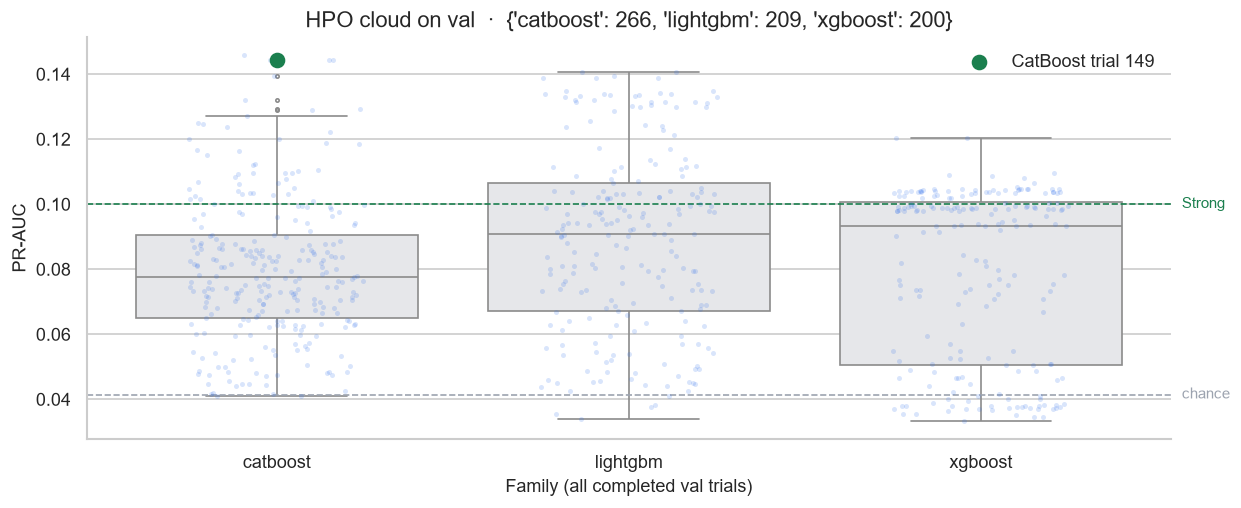

,n,mean,std,p50,p90,best
family,,,,,,
catboost,266,0.080,0.022,0.078,0.109,0.146
lightgbm,209,0.089,0.028,0.091,0.131,0.141
xgboost,200,0.079,0.026,0.093,0.104,0.120


In [7]:
ok = leaderboard[leaderboard["status"] == "ok"].copy()
# Keep the three tree families that actually moved; HPO dumps are large.
fam = ok[ok["family"].isin(["catboost", "lightgbm", "xgboost"])]
# Drop duplicate named aliases of the same metrics
fam = fam.drop_duplicates(subset=["run_id"])

fig, ax = plt.subplots(figsize=(10.5, 4.4))
sns.boxplot(
    data=fam, x="family", y="pr_auc", ax=ax,
    color="#E5E7EB", fliersize=2, linewidth=1,
)
sns.stripplot(
    data=fam, x="family", y="pr_auc", ax=ax,
    color=ACCENT, alpha=0.18, size=3, jitter=0.25,
)
hline(ax, prev_val, "chance", MUTED)
hline(ax, STRONG["pr_auc"], "Strong", GREEN)
ax.scatter([0], [champion["pr_auc"]], color=GREEN, s=70, zorder=5, label="CatBoost trial 149")
ax.set_ylabel("PR-AUC")
ax.set_xlabel("Family (all completed val trials)")
ax.set_title(f"HPO cloud on val  ·  {fam['family'].value_counts().to_dict()}")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "06_hpo_spread.png")
plt.show()

summary = (fam.groupby("family")["pr_auc"]
           .agg(n="count", mean="mean", std="std", p50="median", p90=lambda s: s.quantile(0.9), best="max")
           .round(3))
display(summary)


## 6. Seed stability and calibration

The peak 0.144 used seed 42 **during HPO**. Re-fitting the same hyperparameters on seeds 42 / 123 / 2026 does **not** repeat 0.144. Mean PR-AUC is about **0.080 ± 0.027**.

That is why the freeze keeps trial 149 as the paper champion but **ships `catboost_tuned` (seed 2026) + Platt**.


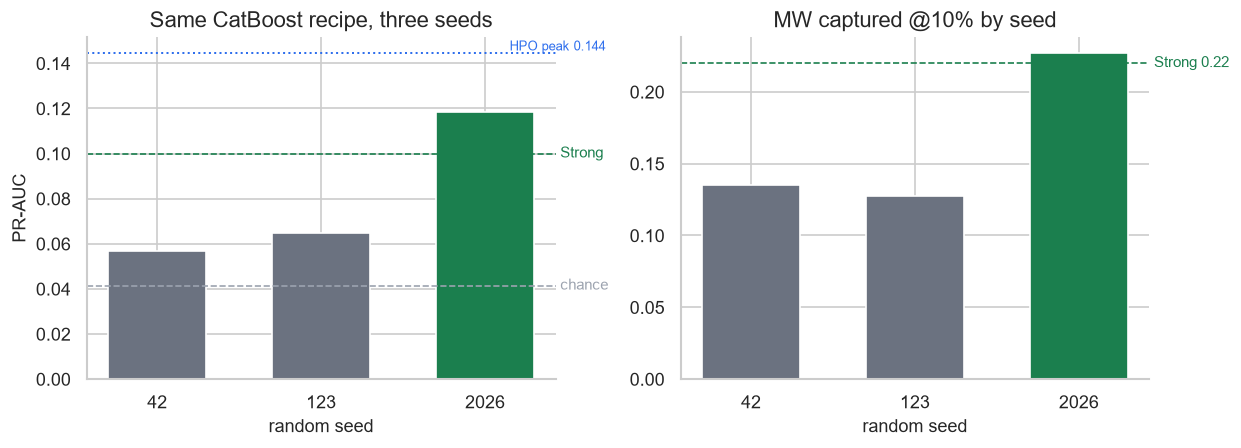

seed,pr_auc,roc_auc,log_loss,withdrawn_mw_capture_at_10pct,goal
42,0.057,0.638,0.204,0.135,below_strong
123,0.065,0.679,0.194,0.127,below_strong
2026,0.119,0.785,0.160,0.227,strong


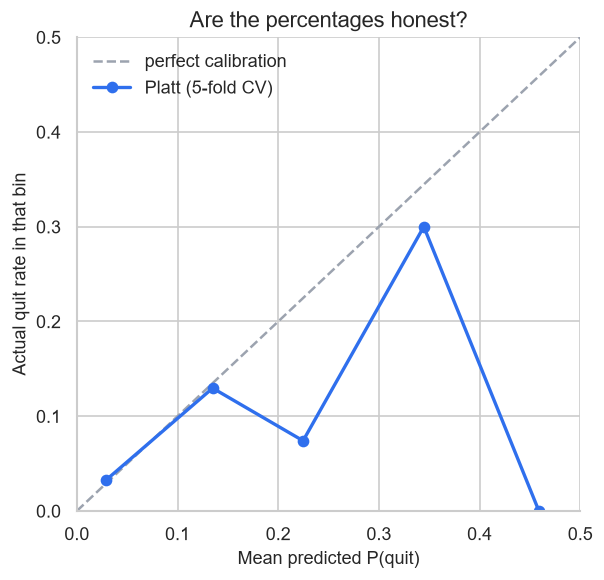

Use **Platt** for quoted probabilities. Isotonic looks nicer if you fit it on all of val, but CV ranking PR-AUC drops (0.095) — that is overfitting the calibrator.

stage,pr_auc,brier,ece,log_loss
CatBoost tuned raw,0.1213,0.0407,0.0139,0.1564
Platt (CV primary),0.1200,0.0385,0.0066,0.1529
Isotonic (CV),0.0951,0.0385,0.0046,0.1567


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
axes[0].bar(seeds["seed"].astype(int).astype(str), seeds["pr_auc"], color=[GRAY, GRAY, GREEN], width=0.6)
hline(axes[0], prev_val, "chance", MUTED)
hline(axes[0], STRONG["pr_auc"], "Strong", GREEN)
axes[0].axhline(champion["pr_auc"], color=ACCENT, ls=":", lw=1.2)
axes[0].text(2.15, champion["pr_auc"], "HPO peak 0.144", color=ACCENT, fontsize=8, va="bottom")
axes[0].set_title("Same CatBoost recipe, three seeds")
axes[0].set_xlabel("random seed")
axes[0].set_ylabel("PR-AUC")

axes[1].bar(seeds["seed"].astype(int).astype(str), seeds["withdrawn_mw_capture_at_10pct"],
            color=[GRAY, GRAY, GREEN], width=0.6)
hline(axes[1], STRONG["mw"], "Strong 0.22", GREEN)
axes[1].set_title("MW captured @10% by seed")
axes[1].set_xlabel("random seed")
fig.tight_layout()
savefig(fig, "07_seed_stability.png")
plt.show()

display(seeds[["seed", "pr_auc", "roc_auc", "log_loss", "withdrawn_mw_capture_at_10pct", "goal"]]
        .style.format({"pr_auc": "{:.3f}", "roc_auc": "{:.3f}", "log_loss": "{:.3f}",
                       "withdrawn_mw_capture_at_10pct": "{:.3f}", "seed": "{:.0f}"})
        .hide(axis="index"))

# Reliability (Platt CV): predicted % vs actual quit rate
rel = platt_cv["reliability"]
fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.plot([0, 0.5], [0, 0.5], color=MUTED, ls="--", label="perfect calibration")
ax.plot(rel["mean_predicted"], rel["fraction_positive"], "o-", color=ACCENT, lw=2, label="Platt (5-fold CV)")
ax.set_xlabel("Mean predicted P(quit)")
ax.set_ylabel("Actual quit rate in that bin")
ax.set_title("Are the percentages honest?")
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.5)
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "08_calibration_reliability.png")
plt.show()

cal_tbl = pd.DataFrame([
    {"stage": "CatBoost tuned raw", "pr_auc": deploy["pr_auc"], "brier": deploy["brier"],
     "ece": deploy["ece"], "log_loss": deploy["log_loss"]},
    {"stage": "Platt (CV primary)", "pr_auc": platt_cv["pr_auc"], "brier": platt_cv["brier"],
     "ece": platt_cv["ece"], "log_loss": platt_cv["log_loss"]},
    {"stage": "Isotonic (CV)", "pr_auc": iso_cv["pr_auc"], "brier": iso_cv["brier"],
     "ece": iso_cv["ece"], "log_loss": iso_cv["log_loss"]},
])
display(Markdown("Use **Platt** for quoted probabilities. Isotonic looks nicer if you fit it on all of val, but CV ranking PR-AUC drops (0.095) — that is overfitting the calibrator." ))
display(cal_tbl.style.format("{:.4f}", subset=["pr_auc", "brier", "ece", "log_loss"]).hide(axis="index"))


## 7. Feature ablations (untuned CatBoost / LightGBM)

Each bar is “same model, drop or add one feature family,” still on val. This is **not** the tuned champion. It tells us which inputs were carrying signal before HPO.


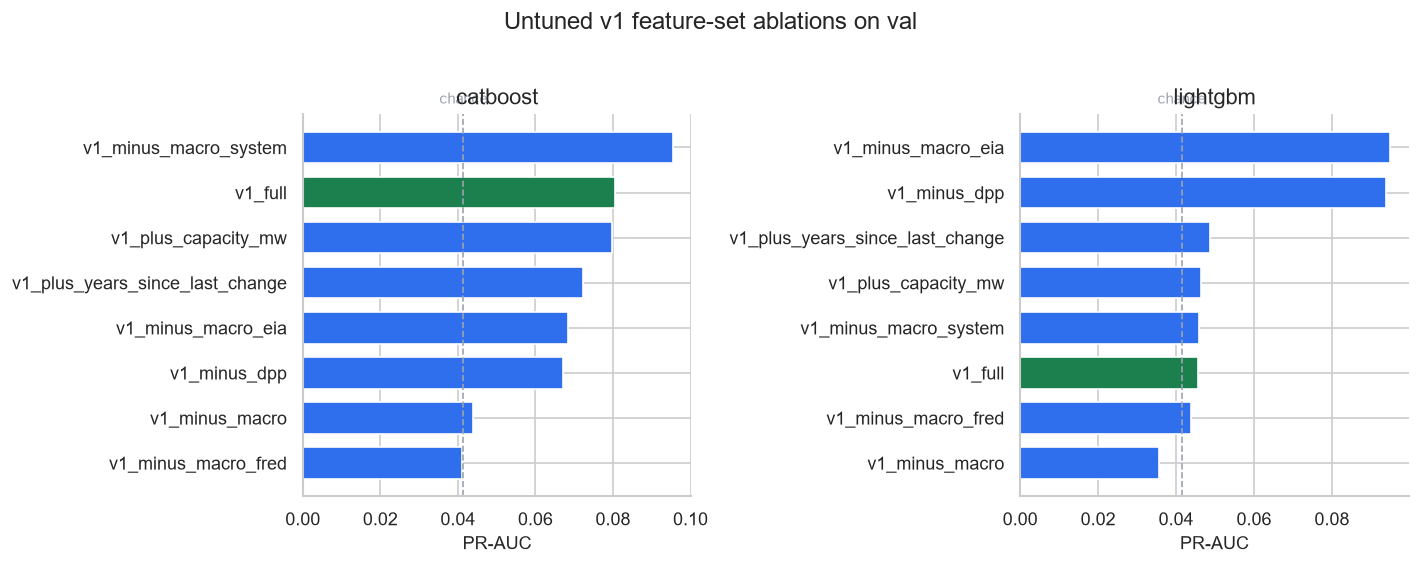

family,catboost,lightgbm
ablation,,
v1_full,0.081,0.046
v1_minus_dpp,0.067,0.094
v1_minus_macro,0.044,0.035
v1_minus_macro_eia,0.068,0.095
v1_minus_macro_fred,0.041,0.044
v1_minus_macro_system,0.095,0.046
v1_plus_capacity_mw,0.080,0.046
v1_plus_years_since_last_change,0.072,0.049


On **CatBoost**, dropping FRED/macro hurts a lot. Dropping the system-wide withdrawal features can *raise* untuned PR-AUC — those columns are easy to overfit. On **LightGBM**, dropping DPP or EIA sometimes *helps* the default model. Take this as “these families are unstable,” not as a recipe to delete them from the champion.

In [9]:
abl_rows = []
for family, runs in ablation_raw.items():
    if not isinstance(runs, dict):
        continue
    for name, m in runs.items():
        if isinstance(m, dict) and "pr_auc" in m:
            abl_rows.append({
                "family": family,
                "ablation": name,
                "pr_auc": m["pr_auc"],
                "roc_auc": m.get("roc_auc"),
                "log_loss": m.get("log_loss"),
                "n_features": m.get("n_features"),
            })
abl = pd.DataFrame(abl_rows)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharex=False)
for ax, fam in zip(axes, ["catboost", "lightgbm"]):
    sub = abl[abl["family"] == fam].sort_values("pr_auc")
    colors = [GREEN if a == "v1_full" else ACCENT for a in sub["ablation"]]
    ax.barh(sub["ablation"], sub["pr_auc"], color=colors, height=0.7)
    vline(ax, prev_val, "chance", MUTED)
    ax.set_title(fam)
    ax.set_xlabel("PR-AUC")
fig.suptitle("Untuned v1 feature-set ablations on val", y=1.02)
fig.tight_layout()
savefig(fig, "09_ablations.png")
plt.show()

display(abl.pivot(index="ablation", columns="family", values="pr_auc").round(3))
display(Markdown(
    "On **CatBoost**, dropping FRED/macro hurts a lot. Dropping the system-wide withdrawal features "
    "can *raise* untuned PR-AUC — those columns are easy to overfit. On **LightGBM**, dropping DPP or EIA "
    "sometimes *helps* the default model. Take this as “these families are unstable,” not as a recipe to delete them from the champion."
))


## 8. What did not work

Neural nets, AutoGluon, logistic regression, and survival models sit near chance. NASNet is **closed** (no more training budget). FT-Transformer beats TabM but still misses Strong (`PR-AUC ≥ 0.10`).


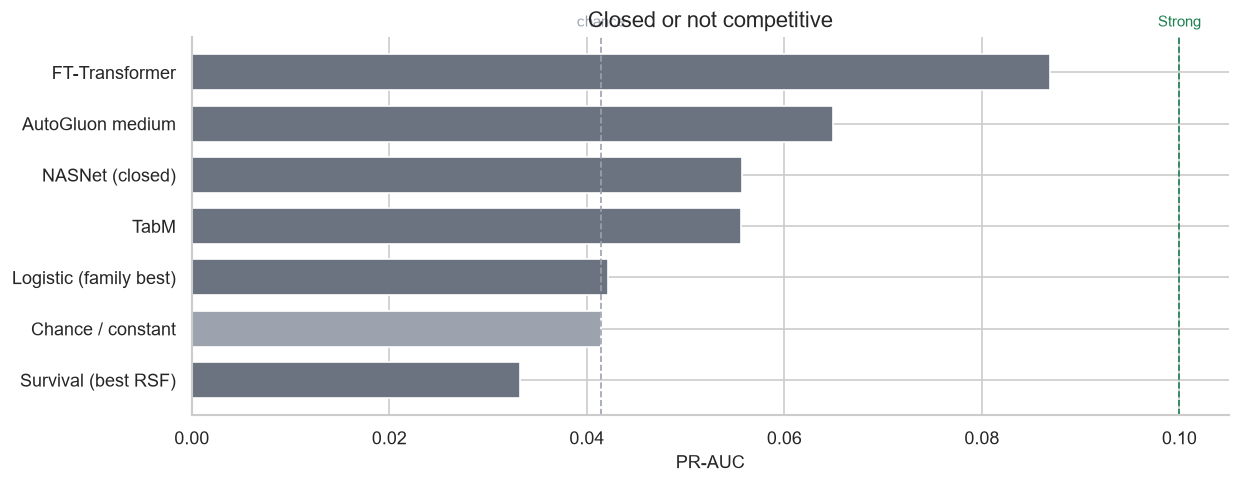

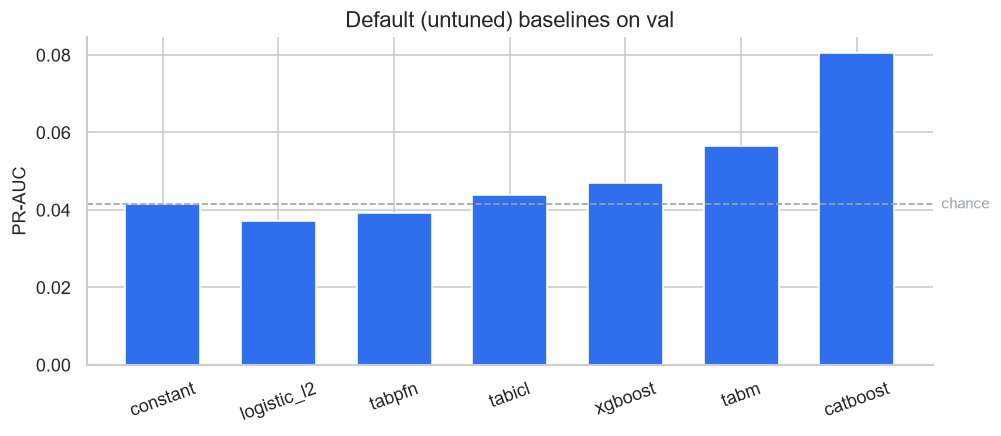

Survival tournament (12m risk aligned to modeling val):

# Survival tournament (validation only)

**Test / score sealed.** 12m risk aligned to modeling val where possible.

| model | status | pr_auc | roc_auc | P@10% | R@10% | MW@10% | alignment |
|-------|--------|--------|---------|-------|-------|--------|-----------|
| discrete_logistic | ok | 0.03914563404350931 | 0.47066510576896897 | 0.0 | 0.0 | 0.0 | aligned to modeling val: 1666/1666 rows |
| cox_tv | ok | 0.029496198164842256 | 0.3509070449121087 | 0.0 | 0.0 | 0.0 | aligned to modeling val: 1666/1666 rows |
| cox_ph | skipped | None | None | None | None | None | CoxPH fit failed: delta contains nan value(s). Convergence halted. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model |
| boost_lgbm | ok | 0.03794232353332842 | 0.3594148448631039 | 0.0 | 0.0 | 0.0 | aligned to modeling val: 1666/1666 rows |
| xgb_aft | skipped | None | None | None | None | Non

In [10]:
other = headline[headline["family"].isin(["neural", "automl", "linear", "survival", "baseline"])].copy()
other = other.sort_values("pr_auc")
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.barh(other["model"], other["pr_auc"], color=[MUTED if r == "no-skill" else GRAY for r in other["role"]], height=0.7)
vline(ax, prev_val, "chance", MUTED)
vline(ax, STRONG["pr_auc"], "Strong", GREEN)
ax.set_xlabel("PR-AUC")
ax.set_title("Closed or not competitive")
fig.tight_layout()
savefig(fig, "10_not_competitive.png")
plt.show()

untuned = baselines.copy()
fig, ax = plt.subplots(figsize=(8.5, 3.8))
order_u = ["constant", "logistic_l2", "tabpfn", "tabicl", "xgboost", "tabm", "catboost"]
untuned["model"] = pd.Categorical(untuned["model"], order_u, ordered=True)
untuned = untuned.dropna(subset=["model"]).sort_values("model")
ax.bar(untuned["model"], untuned["pr_auc"], color=ACCENT, width=0.65)
hline(ax, prev_val, "chance", MUTED)
ax.set_title("Default (untuned) baselines on val")
ax.set_ylabel("PR-AUC")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
savefig(fig, "11_untuned_baselines.png")
plt.show()

display(Markdown("Survival tournament (12m risk aligned to modeling val):"))
print(surv_md)


## 9. General observations

1. **Trees are the only family that clearly beat chance.** CatBoost wins the freeze. LightGBM is close on PR-AUC and actually captures the most withdrawn MW (45%), but its log-loss misses Strong, so it is not the champion.

2. **The job is triage, not a crystal ball.** Flag the top 10% and you catch about **1 in 3** withdrawals and **1 in 3** exiting MW. Most flagged projects still stay in the queue (precision ~13–16% vs a 4% base rate).

3. **Train and val are different worlds.** Dropout rate falls from **12.4%** (2020–22) to **4.1%** (2023). Always score models against the val base rate, not the train rate.

4. **The 0.144 peak is fragile.** Same hyperparameters, new seeds: 0.057 / 0.065 / 0.119. Do not treat the leaderboard number as a guaranteed 2024 result.

5. **Ship probabilities from Platt, ranks from raw CatBoost.** Calibration makes Brier / ECE / log-loss better without really changing who is at the top of the list (PR-AUC stays ~0.12). Skip isotonic for selection.

6. **Neural / AutoML / survival / logistic are done for Phase 1.** NASNet is closed. FT-Transformer is a weak challenger. Survival models are at or below chance.

7. **Test 2024 is still locked.** Everything in this notebook is val. Opening test is a one-time decision after the freeze is approved — no more tuning after that.

**One sentence:** CatBoost is good enough to rank which queue projects are at risk; it is not good enough to declare that a given project will quit; everything else we tried is near a coin flip.


In [11]:
print("Figures written to", FIG)
for p in sorted(FIG.glob("*.png")):
    print(" ", p.name)


Figures written to C:\Users\Magjun\Documents\Team-8-XternChallenge-\Data\quality_reports\modeling\figures
  01_splits.png
  02_auc_meaning.png
  03_pr_auc_headline.png
  04_roc_mw_logloss.png
  05_ops_at_10.png
  06_hpo_spread.png
  07_seed_stability.png
  08_calibration_reliability.png
  09_ablations.png
  10_not_competitive.png
  11_untuned_baselines.png
